# Data Project Part 2: Advanced Analysis
Data set chosen: Palmer Archipelago (Antarctica) penguin data  
url: https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data

### About the data set:
I used the simplified version of the data set:

penguins_size.csv: Simplified data from original penguin data sets. Contains variables:

species: penguin species (Chinstrap, Adélie, or Gentoo)  
culmen_length_mm: culmen length (mm)  
culmen_depth_mm: culmen depth (mm)  
flipper_length_mm: flipper length (mm)  
body_mass_g: body mass (g)  
island: island name (Dream, Torgersen, or Biscoe) in the Palmer Archipelago (Antarctica)  
sex: penguin sex

### Analysis Workflow

Each analysis follows the same workflow:

> **Refine → Analyze → Interpret**

```text
Distribution Analysis
├── Body Mass
│   └── Refine → Analyze → Interpret
│
└── Flipper Length
    └── Refine → Analyze → Interpret

Correlation Analysis
├── Flipper Length ↔ Body Mass
│   └── Refine → Analyze → Interpret
│
└── Culmen Length ↔ Body Mass
    └── Refine → Analyze → Interpret

Hypothesis Testing
├── Male vs. Female Body Mass
│   └── Refine → Analyze → Interpret
│
└── Adelie vs. Gentoo Flipper Length
    └── Refine → Analyze → Interpret

### load the penguins dataset

In [119]:
import numpy as np
from scipy import stats
from scipy.stats import norm
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns
from pathlib import Path

In [120]:
# Reusable code blocks

# plot histogram and density plot and overlay with normal distribution
def plot_hist_normal(
    data: pd.DataFrame,
    column:str,
    title:str|None = None,
    bins:int = 20,
    num_points:int = 500,
    ax:plt.Axes|None = None) -> plt.Axes:
    """Plot a histogram, observed density, and fitted normal distribution"""
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 6))
        
    values = data[column].dropna()
    median = values.median()
    mean = values.mean()
    std = values.std()
    
    # observed distribution
    sns.histplot(data=values, bins=bins, stat="density", kde=True, label="Observed Density", ax=ax)
    
    # Create evenly spaced x-values across the observed range.
    x = np.linspace(start=values.min(), stop=values.max(), num=num_points)
    
    # Overlay the theoretical normal distribution.
    ax.plot(
        x, 
        norm.pdf(x=x, loc=mean, scale=std), 
        color="red", 
        linestyle="--", 
        label="Theoretical Density"
    )
    
    ax.set(
        title=title or f"Distribution of {column.replace("_", " ")}",
        xlabel=column.replace("_", " ").title(),
        ylabel="density"
    )
    
    ax.legend()
    
    #format text
    ax.text(
        x=0.02, y=0.98,
        s=f"mean = {mean:.2f}\n"
        f"Median = {median:.2f}\n"
        f"SD = {std:.2f}",
        transform=ax.transAxes,
        va="top"
    )
    
    return ax

# QQ plots for both variables
def plot_qq(
    data: pd.DataFrame,
    column: str,
    title: str|None = None,
    ax: plt.Axes|None = None
) -> plt.Axes:
    """Plot a normal Q-Q plot with a quartile-fitted reference line."""
    if ax is None:
        fig, ax = plt.subplots(figsize(6, 5))
        
    values = data[column].dropna()
    
    plt.sca(ax)
    stats.probplot(values, dist="norm", plot=plt)

    ax.set_title(title if title is not None else f"Q-Q plot of {column.replace("_", " ")}")
    ax.grid(visible=True, linestyle="--", alpha=0.7)
    
    return ax

# box plots by categorical variable
def plot_boxplot(
    data: pd.DataFrame,
    x_categorical:str,
    y_numerical:str,
    title:str|None = None,
    ax:plt.Axes|None = None) -> plt.Axes:
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 6))
    
    sns.boxplot(
        data=data,
        x=x_categorical,
        y=y_numerical,
        ax=ax
    )
    
    ax.set(
        title=title or f"{y_numerical.replace("_", " ")} by {x_categorical.replace("_", " ")}",
        xlabel=x_categorical.replace("_", " ").title(),
        ylabel=y_numerical.replace("_", " ").title()
    )
    
    ax.grid(visible=True, linestyle="--", alpha=0.7)
        
    return ax

def plot_scatterplot(
    data: pd.DataFrame,
    xvar:str,
    yvar:str,
    title:str|None = None,
    hue_var:str|None = None,
    reg_line:bool = False,
    ax:plt.Axes|None = None) -> plt.Axes:
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 6))
        
    sns.scatterplot(
        data=data,
        x=xvar,
        y=yvar,
        hue=hue_var,
        ax=ax
    )
    
    if(reg_line):
        sns.regplot(
            data=data,
            x=xvar,
            y=yvar,
            scatter=False,
            ax=ax
        )
    
    ax.set(
        title=title or f"{xvar.replace("_", " ")} vs. {yvar.replace("_", " ")}",
        xlabel=xvar.replace("_", " ").title(),
        ylabel=yvar.replace("_", " ").title()
    )
        
    ax.grid(visible=True, linestyle="--", alpha=0.7)
            
    return ax

In [121]:
#1. load the penguins dataset
project_root = Path.cwd().parents[0]
fname = project_root / "datasets" / "penguins_size.csv"

# verify the path
# print(fname)

df = pd.read_csv(fname)

### Explore the dataset


In [122]:
# 2. Explore the dataset
# 2.1 Dataset dimensions
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

#examine variable names
print(df.columns.tolist())

# view the dataset
display(df.head())
df.info()


Rows: 344
Columns: 7
['species', 'island', 'culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


## 1. Probability and Distributions Analysis

variable1: body_mass_g  
variable2: flipper_length_mm

### 1.1 Body Mass Distribution Analysis

#### 1.1.1 Refinement

In [123]:
body_mass_n = df["body_mass_g"].notna().sum()
body_mass_missing = df["body_mass_g"].isna().sum()

print(f"Original observations: {len(df)}")
print(f"Missing body mass observations: {body_mass_missing}")
print(f"Usable body mass observations: {body_mass_n}")

Original observations: 344
Missing body mass observations: 2
Usable body mass observations: 342


#### 1.1.2 Descriptive statistics

In [124]:
# data used in analysis after removing the missing
body_mass_data = df["body_mass_g"].dropna()

body_mass_data.describe()

count     342.000000
mean     4201.754386
std       801.954536
min      2700.000000
25%      3550.000000
50%      4050.000000
75%      4750.000000
max      6300.000000
Name: body_mass_g, dtype: float64

#### 1.1.3 Analysis

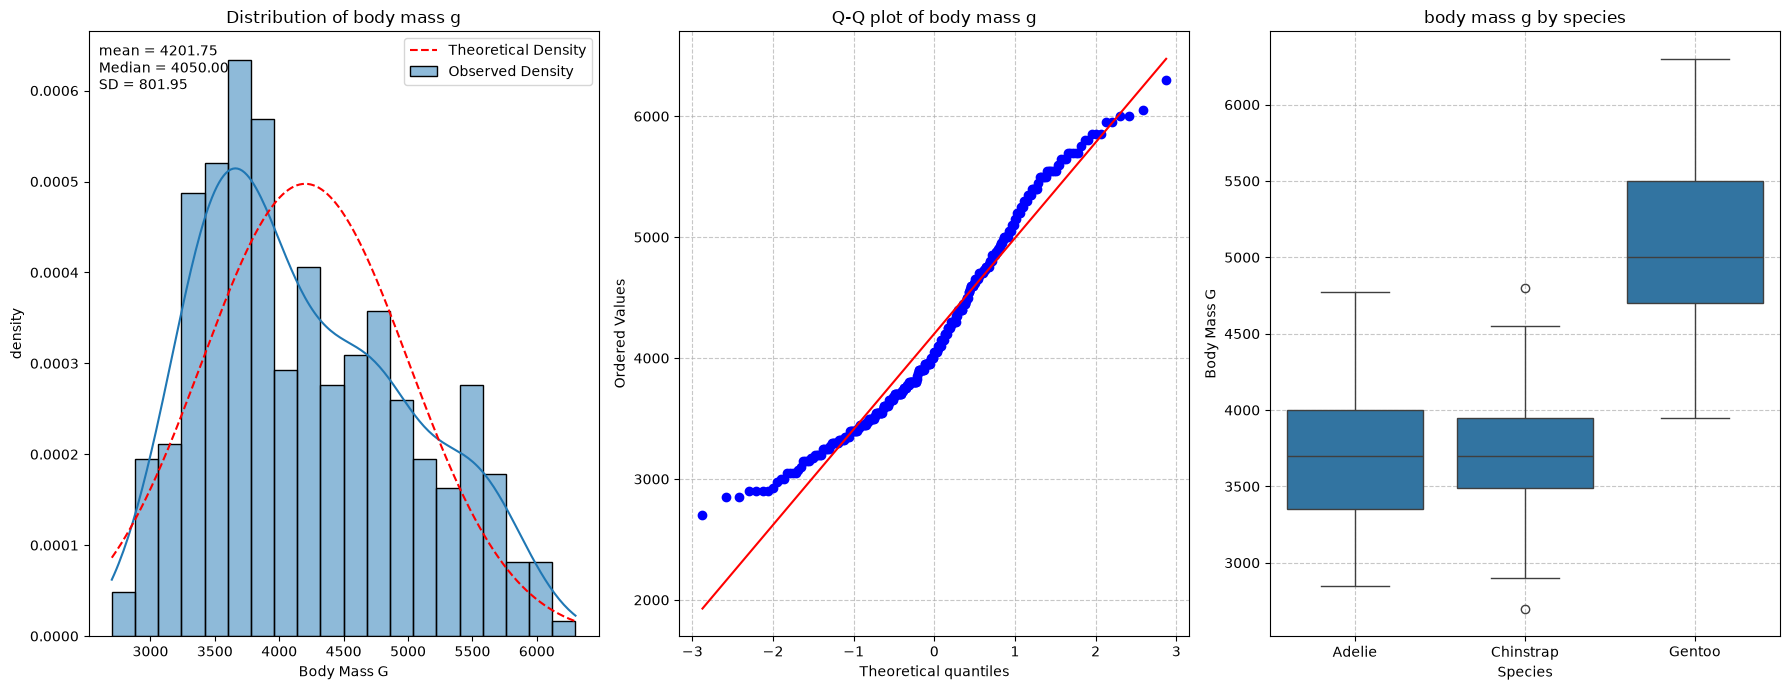

In [125]:
# visualizations
# compare observed and theoretical distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
plot_hist_normal(data=df, column="body_mass_g", ax=axes[0])
plot_qq(data=df, column="body_mass_g", ax=axes[1])
plot_boxplot(data=df, x_categorical="species", y_numerical="body_mass_g", ax=axes[2])

plt.tight_layout()



##### Body Mass Analysis Interpretation
The analysis uses 342 of the 344 observations because 2 observations are missing. The observed density does not closely match the theoretical normal distribution, indicating that body mass is not normally distributed. The distribution shows a noticeable right skew with the mean (4201.75 grams) greater than the median (4050 grams).  
The departure from normality is also supported by the Q-Q plot, where the observed quantiles deviate from the theoretical normal line, particularly at the upper and lower tails.  
The species-body mass box plot shows substantial differences in body mass among species, with Gentoo having considerably higher body mass than Adelie and Chinstrap. These differences likely contribute to the shape of the overall distribution.

### 1.2 Flipper length Distribution Analysis

#### 1.2.1 Refinement

In [126]:
flipper_length_n = df["flipper_length_mm"].notna().sum()
flipper_length_missing = df["flipper_length_mm"].isna().sum()

print(f"Original observations: {len(df)}")
print(f"Missing flipper length observations: {flipper_length_missing}")
print(f"Usable flipper length observations: {flipper_length_n}")

Original observations: 344
Missing flipper length observations: 2
Usable flipper length observations: 342


#### 1.2.2 Descriptive statistics

In [135]:
# data used in analysis after removing the missing
flipper_length_data = df["flipper_length_mm"].dropna()

flipper_length_data.describe()

count    342.000000
mean     200.915205
std       14.061714
min      172.000000
25%      190.000000
50%      197.000000
75%      213.000000
max      231.000000
Name: flipper_length_mm, dtype: float64

#### 1.2.3 Distribution Analysis

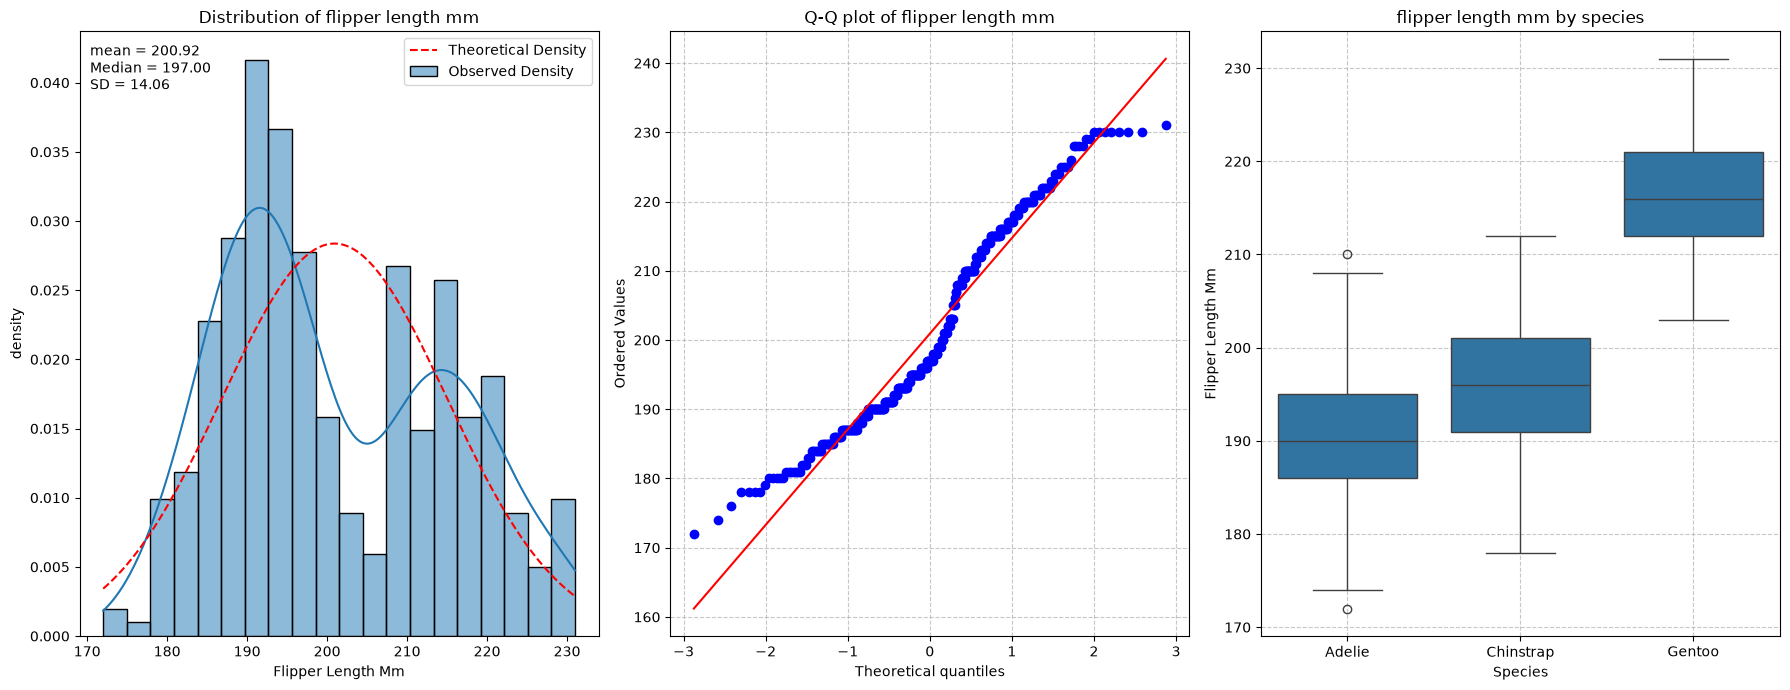

In [128]:
# visualizations
# compare observed and theoretical distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
plot_hist_normal(data=df, column="flipper_length_mm", ax=axes[0])
plot_qq(data=df, column="flipper_length_mm", ax=axes[1])
plot_boxplot(data=df, x_categorical="species", y_numerical="flipper_length_mm", ax=axes[2])

plt.tight_layout()

##### Flipper Length Analysis Interpretation
The analysis uses 342 of the 344 observations because 2 observations are missing. The observed density does not closely match the theoretical normal distribution, indicating that flipper length is not normally distributed. The distribution appears bimodal, while the mean (200.97 mm) is relatively close to the median (197 mm), suggesting skewness is not the primary feature of the distribution.  
The departure from normality is also supported by the Q-Q plot, where the observed quantiles deviate from the theoretical normal line, particularly at the upper and lower tails.  
The species-flipper length box plot shows substantial differences in flipper length among species, with the Gentoo having the highest values, while Adelie and Chinstrap have lower values. These differences among species likely contribute to the bi-modal shape of the overall distribution, especially that the two modes appear close to the median of the Gentoo and the Adelie.

## 2. Correlation Analysis

pair1: flipper_length_mm  <>  body_mass_g  
variable2: culmen_length_mm  <>  body_mass_g


```text
Correlation Analysis
├── Refinement
├── Scatterplot
├── Pearson Correlation
├── Spearman Correlation
├── Significance Testing
└── Interpretation

### 2.1 Flipper Length vs. Body Mass

#### 2.1.1 Refinement

In [129]:
flipper_mass = df[["flipper_length_mm", "body_mass_g", "species"]].dropna()

print("Original observations:", len(df))
print("Usable observations:", len(flipper_mass))
print("Removed observations:", len(df) - len(flipper_mass))

Original observations: 344
Usable observations: 342
Removed observations: 2


#### 2.1.2 Scatterplot

<Axes: title={'center': 'flipper length mm vs. body mass g'}, xlabel='Flipper Length Mm', ylabel='Body Mass G'>

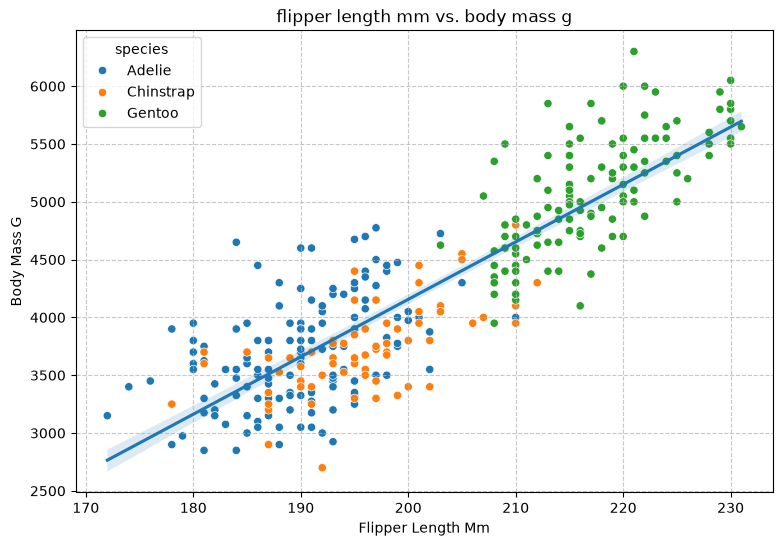

In [130]:
plot_scatterplot(data=flipper_mass, xvar="flipper_length_mm", yvar="body_mass_g", hue_var="species", reg_line=True)

#### 2.1.3 Correlation Coeffiecients

In [131]:
pearson = stats.pearsonr(x=flipper_mass["flipper_length_mm"], y=flipper_mass["body_mass_g"])
# print(f"Pearson: r = {pearson.statistic:.3f}, p = {pearson.pvalue:.4f}")

spearman = stats.spearmanr(a=flipper_mass["flipper_length_mm"], b=flipper_mass["body_mass_g"])
# print(f"Spearman: r = {spearman.statistic:.3f}, p = {spearman.pvalue:.4f}")

print(f"The coefficient of determination Pearson R-squared: {pearson.statistic ** 2:.4f}")

alpha = 0.05

summary = pd.DataFrame({
    "Method": ["Pearson", "Spearman"],
    "Correlation": [
        pearson.statistic,
        spearman.statistic
    ],
    "p-value": [
        pearson.pvalue,
        spearman.pvalue
    ],
    "Significant at 0.05": [
        pearson.pvalue <= 0.05,
        spearman.pvalue <= 0.05
    ]
    
}).style.format({
    "Correlation": "{:.3f}",
    "p-value": "{:.4f}"
})

summary

The coefficient of determination Pearson R-squared: 0.7590


,Method,Correlation,p-value,Significant at 0.05
0,Pearson,0.871,0.0000,True
1,Spearman,0.840,0.0000,True


##### flipper length vs. Body Mass Correlation Analysis Interpretation
The analysis uses 342 of the 344 observations because 2 observations are missing from the values used.  
The scatter plot shows a strong positive association between the flipper length and the body mass. Correlation coeffients support the same with pearson's correlation r = 0.871, suggesting a strong linear relationship, while the Spearman $\rho$ = 0.840 suggesting a strong monotonic relationship.  
Both correlations were statistically significant with p-value < 0.05, providing sufficient evidence against the null hypothesis that the population correlation is zero.  
The similar values between pearson's and Spearman's coefficients suggest that the relationship is approximately linear and consistently monotonic (i.e. variables increase together).  
The R² = 0.759, suggests that approximately 75.9% of the sample variation in flipper length is associated with the linear relationship with body mass.  
The correlation shows association and does not establish causation. 

### 2.2 Culmen Length vs. Body Mass

#### 2.2.1 Refinement

In [132]:
culmen_mass = df[["culmen_length_mm", "body_mass_g", "species"]].dropna()

print("Original observations:", len(df))
print("Usable observations:", len(culmen_mass))
print("Removed observations:", len(df) - len(culmen_mass))

Original observations: 344
Usable observations: 342
Removed observations: 2


#### 2.2.2 Scatter plot

<Axes: title={'center': 'culmen length mm vs. body mass g'}, xlabel='Culmen Length Mm', ylabel='Body Mass G'>

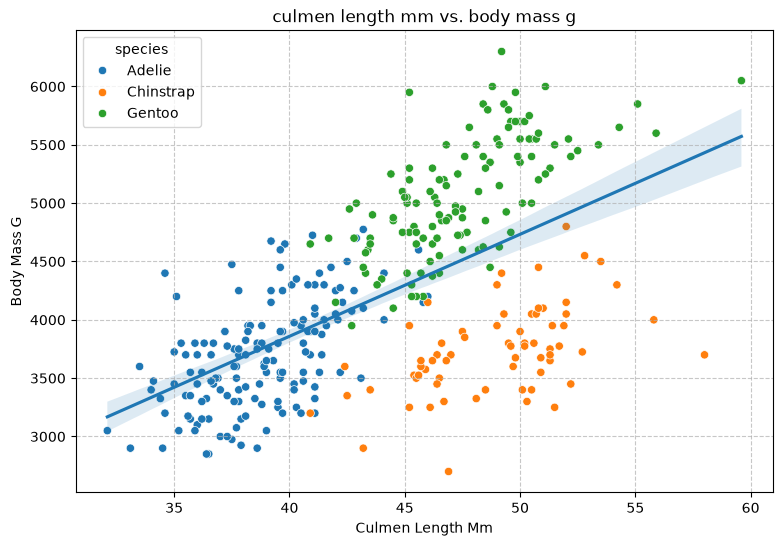

In [133]:
plot_scatterplot(data=culmen_mass, xvar="culmen_length_mm", yvar="body_mass_g", hue_var="species", reg_line=True)

#### 2.2.3 Correlation Coefficiets

In [134]:
pearson = stats.pearsonr(x=culmen_mass["culmen_length_mm"], y=culmen_mass["body_mass_g"])
# print(f"Pearson: r = {pearson.statistic:.3f}, p = {pearson.pvalue:.4f}")

spearman = stats.spearmanr(a=culmen_mass["culmen_length_mm"], b=culmen_mass["body_mass_g"])
# print(f"Spearman: r = {spearman.statistic:.3f}, p = {spearman.pvalue:.4f}")

print(f"The coefficient of determination Pearson R-squared: {pearson.statistic ** 2:.4f}")

alpha = 0.05

summary = pd.DataFrame({
    "Method": ["Pearson", "Spearman"],
    "Correlation": [
        pearson.statistic,
        spearman.statistic
    ],
    "p-value": [
        pearson.pvalue,
        spearman.pvalue
    ],
    "Significant at 0.05": [
        pearson.pvalue <= 0.05,
        spearman.pvalue <= 0.05
    ]
    
}).style.format({
    "Correlation": "{:.3f}",
    "p-value": "{:.4f}"
})

summary

The coefficient of determination Pearson R-squared: 0.3542


,Method,Correlation,p-value,Significant at 0.05
0,Pearson,0.595,0.0000,True
1,Spearman,0.584,0.0000,True


##### Culmen length vs. Body Mass Correlation Analysis Interpretation
The analysis uses 342 of the 344 observations because 2 observations are missing from the values used.  
The scatter plot shows a moderate positive association between the Culmen length and the body mass. Correlation coeffients support the same with pearson's correlation r = 0.595, suggesting a moderate linear relationship, while the Spearman $\rho$ = 0.584 suggesting a moderate monotonic relationship.  
Both correlations were statistically significant with p-value < 0.05, providing sufficient evidence against the null hypothesis that the population correlation is zero.  
The similar values between pearson's and Spearman's coefficients suggest that the relationship is approximately linear and consistently monotonic (i.e. variables increase).  
The R² = 0.3542, suggests that approximately 35.42% of the sample variation in culmen length is associated with the linear relationship with body mass.  
The correlation shows association and does not establish causation. 